# Training a neural network on MNIST with Keras

This simple example demonstrates how to plug TensorFlow Datasets (TFDS) into a Keras model.


Copyright 2020 The TensorFlow Datasets Authors, Licensed under the Apache License, Version 2.0

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://www.tensorflow.org/datasets/keras_example"><img src="https://www.tensorflow.org/images/tf_logo_32px.png" />View on TensorFlow.org</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/datasets/blob/master/docs/keras_example.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/datasets/blob/master/docs/keras_example.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/datasets/docs/keras_example.ipynb"><img src="https://www.tensorflow.org/images/download_logo_32px.png" />Download notebook</a>
  </td>
</table>

In [12]:
import tensorflow as tf

In [13]:

import tensorflow_datasets as tfds

## Step 1: Create your input pipeline

Start by building an efficient input pipeline using advices from:
* The [Performance tips](https://www.tensorflow.org/datasets/performances) guide
* The [Better performance with the `tf.data` API](https://www.tensorflow.org/guide/data_performance#optimize_performance) guide


### Load a dataset

Load the MNIST dataset with the following arguments:

* `shuffle_files=True`: The MNIST data is only stored in a single file, but for larger datasets with multiple files on disk, it's good practice to shuffle them when training.
* `as_supervised=True`: Returns a tuple `(img, label)` instead of a dictionary `{'image': img, 'label': label}`.

In [14]:
# Load the MNIST dataset from TensorFlow Datasets
(ds_train, ds_test), ds_info = tfds.load(
    'mnist',                     # name of the dataset
    split=['train', 'test'],     # get training and test sets separately
    shuffle_files=True,          # shuffle data files before reading (good practice for training)
    as_supervised=True,          # return data as (image, label) tuples instead of a dictionary
    with_info=True,              # also return dataset metadata (e.g., number of samples)
)

In [15]:
for img, lbl in ds_train.take(1):
    print("Image:", img)
    print("Label:", lbl)

Image: tf.Tensor(
[[[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0

2025-11-11 22:05:15.234349: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


2025-11-11 22:05:15.265549: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-11-11 22:05:15.279011: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


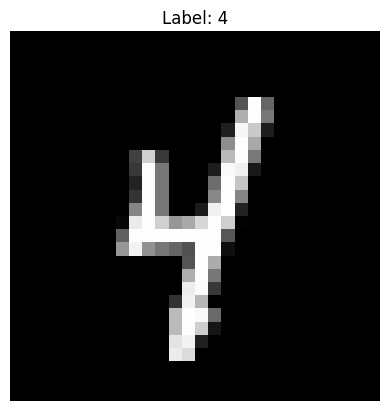

In [16]:
import matplotlib.pyplot as plt

for img, lbl in ds_train.take(1):
    plt.imshow(img.numpy().squeeze(), cmap='gray')
    plt.title(f"Label: {lbl.numpy()}")
    plt.axis("off")

### Build a training pipeline

Apply the following transformations:

* `tf.data.Dataset.map`: TFDS provide images of type `tf.uint8`, while the model expects `tf.float32`. Therefore, you need to normalize images.
* `tf.data.Dataset.cache` As you fit the dataset in memory, cache it before shuffling for a better performance.<br/>
__Note:__ Random transformations should be applied after caching.
* `tf.data.Dataset.shuffle`: For true randomness, set the shuffle buffer to the full dataset size.<br/>
__Note:__ For large datasets that can't fit in memory, use `buffer_size=1000` if your system allows it.
* `tf.data.Dataset.batch`: Batch elements of the dataset after shuffling to get unique batches at each epoch.The batch size is a hyperparameter of gradient descent that controls the number of training samples to work through before the model’s internal parameters are updated.
* `tf.data.Dataset.prefetch`: It is good practice to end the pipeline by prefetching [for performance](https://www.tensorflow.org/guide/data_performance#prefetching).

In [17]:
# Function to normalize the images from uint8 (0-255) to float32 (0-1)
def normalize_img(image, label):
  """Normalizes images: `uint8` -> `float32`."""
  return tf.cast(image, tf.float32) / 255., label                 # normalizes the images by dividing all pixels by 255

# Applying the preprocessing pipeline to the training dataset
ds_train = ds_train.map(                                          # apply normalization function to every tuple (image, label)
    normalize_img, num_parallel_calls=tf.data.AUTOTUNE)           # parallel data processing for better performace

ds_train = ds_train.cache()                                       # stores all data in memory for better performance

ds_train = ds_train.shuffle(ds_info.splits['train'].num_examples) # random shuffle for all data. Prevents that the model learns from recurring patterns

ds_train = ds_train.batch(128)                                    # groups the data into batches of 128 images

ds_train = ds_train.prefetch(tf.data.AUTOTUNE)                    # preloads the next data batch while the current one trains

### Build an evaluation pipeline

Your testing pipeline is similar to the training pipeline with small differences:

 * You don't need to call `tf.data.Dataset.shuffle`.
 * Caching is done after batching because batches can be the same between epochs.

In [18]:
# Same parameters as training pipeline
# Shuffling not needed because model is not learning on test data, so the order doesn't affect evaluation metrics

ds_test = ds_test.map(
    normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.batch(128)
ds_test = ds_test.cache()
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)

## Step 2: Create and train the model

Plug the TFDS input pipeline into a simple Keras model, compile the model, and train it.
* in `tf.keras.optimizers.Adam` you set the learning rate. The learning rate is a hyperparameter that controls how much to change the model in response to the estimated error each time the model weights are updated. Choosing the learning rate is challenging as a too small value may result in a long training process that could get stuck, whereas a too large value may result in learning a sub-optimal set of weights too fast or an unstable training process.
* The number of epochs is a hyperparameter of gradient descent that controls the number of complete passes through the training dataset.

In [19]:
# Build a simple Keras model
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),       # Flatten the 28x28 image into a 784-element vector
  tf.keras.layers.Dense(64, activation='relu'),       # Fully connected hidden layer with 64 neurons and ReLU activation
  tf.keras.layers.Dense(10)                            # Output layer with 10 units (one for each digit 0–9)
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),                             # Adam optimizer with learning rate 0.001
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),  # measures the loss rate of the model
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()],                # shows the accuracy of the model
)

# Train the model
model.fit(
    ds_train,                            # training dataset
    epochs=10,                           # number of full passes through the training data
    validation_data=ds_test,             # evaluate on test data after each epoch
)

Epoch 1/10


469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.4215 - sparse_categorical_accuracy: 0.8864 - val_loss: 0.2259 - val_sparse_categorical_accuracy: 0.9377
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1999 - sparse_categorical_accuracy: 0.9439 - val_loss: 0.1705 - val_sparse_categorical_accuracy: 0.9509
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step - loss: 0.1521 - sparse_categorical_accuracy: 0.9564 - val_loss: 0.1390 - val_sparse_categorical_accuracy: 0.9591
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1246 - sparse_categorical_accuracy: 0.9641 - val_loss: 0.1218 - val_sparse_categorical_accuracy: 0.9652
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1049 - sparse_categorical_accuracy: 0.9698 - val_loss: 0.1088 - val_sparse_categorical_accuracy: 0.9672
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step - loss: 0.0911 - sparse_categorical_accuracy: 0.9732 - val_loss: 0.1059 - val_sparse_categorical_accuracy: 0.9679
Epoch 7/10


![MNIST NN](NN.webp)

## Step 3: Hyperparameter Tuning + Regularization

In [ ]:
# Function to build a model with variable hyperparameters and regularization
def build_model(hidden_units=128, learning_rate=0.001, dropout_rate=0.2, l2_rate=0.0001):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        
        # Hidden layer with L2 regularization
        tf.keras.layers.Dense(
            hidden_units, 
            activation='relu',
            kernel_regularizer=tf.keras.regularizers.l2(l2_rate)
        ),
        
        # Dropout to prevent overfitting
        tf.keras.layers.Dropout(dropout_rate),
        
        # Output layer (logits)
        tf.keras.layers.Dense(10)
    ])
    
    # Compile with chosen learning rate
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
    )
    return model

![RvsG](randomSearchVsGridSearch.png)

In [21]:
# Define a small hyperparameter grid
learning_rates = [0.01, 0.001]
hidden_units_list = [64, 128, 256]
dropout_rates = [0.0, 0.3]  # 0 = no dropout, 0.3 = strong regularization

results = []
best_acc = 0
best_params = None
best_model = None

print("Starting hyperparameter tuning...\n")

for lr in learning_rates:
    for units in hidden_units_list:
        for dr in dropout_rates:
            
            print(f"Testing: lr={lr}, units={units}, dropout={dr}")

            # Build model with current hyperparameters
            model = build_model(
                hidden_units=units, 
                learning_rate=lr, 
                dropout_rate=dr,
                l2_rate=0.0001  # fixed L2 rate
            )

            # Train only for 3 epochs → fast comparison
            history = model.fit(
                ds_train,
                epochs=3, 
                validation_data=ds_test,
                verbose=0
            )
            
            # Last validation accuracy
            val_acc = history.history['val_sparse_categorical_accuracy'][-1]
            results.append((lr, units, dr, val_acc))
            
            # Track the best model
            if val_acc > best_acc:
                best_acc = val_acc
                best_params = (lr, units, dr)
                best_model = model

print("\nBest parameters found:")
print(f"Learning rate = {best_params[0]}")
print(f"Hidden units = {best_params[1]}")
print(f"Dropout rate = {best_params[2]}")
print(f"Validation accuracy = {best_acc:.4f}")


Starting hyperparameter tuning...

Testing: lr=0.01, units=64, dropout=0.0
Testing: lr=0.01, units=64, dropout=0.3
Testing: lr=0.01, units=128, dropout=0.0
Testing: lr=0.01, units=128, dropout=0.3
Testing: lr=0.01, units=256, dropout=0.0
Testing: lr=0.01, units=256, dropout=0.3
Testing: lr=0.001, units=64, dropout=0.0
Testing: lr=0.001, units=64, dropout=0.3
Testing: lr=0.001, units=128, dropout=0.0
Testing: lr=0.001, units=128, dropout=0.3
Testing: lr=0.001, units=256, dropout=0.0
Testing: lr=0.001, units=256, dropout=0.3

Best parameters found:
Learning rate = 0.001
Hidden units = 256
Dropout rate = 0.3
Validation accuracy = 0.9724


In [22]:
# Retrain the best model for more epochs
print("Retraining the best model for 10 epochs...\n")

best_model = build_model(
    hidden_units=best_params[1],
    learning_rate=best_params[0],
    dropout_rate=best_params[2],
    l2_rate=0.0001
)

history = best_model.fit(
    ds_train,
    epochs=10,
    validation_data=ds_test,
    verbose=1
)

print("\nFinal validation accuracy after 10 epochs:",
      history.history['val_sparse_categorical_accuracy'][-1])

Retraining the best model for 10 epochs...

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3898 - sparse_categorical_accuracy: 0.8968 - val_loss: 0.2026 - val_sparse_categorical_accuracy: 0.9500
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2030 - sparse_categorical_accuracy: 0.9508 - val_loss: 0.1558 - val_sparse_categorical_accuracy: 0.9643
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1604 - sparse_categorical_accuracy: 0.9635 - val_loss: 0.1323 - val_sparse_categorical_accuracy: 0.9697
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1405 - sparse_categorical_accuracy: 0.9687 - val_loss: 0.1276 - val_sparse_categorical_accuracy: 0.9715
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1271 - sparse_categorical_accuracy: 0.9727 - val_loss: 0.1168 - val_sparse_categorical_accuracy: 0.9752
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1171 - sparse_categorical_accuracy: 0.9756 - val_loss: 0.1083 - 